# Week 7 - Advanced Models

Train a CatBoost gradient-boosted tree regressor on the Week 6 engineered feature set. Hyperparameters are selected with May 2026 as an internal validation month, then the selected model is refit on the complete 30-month training window from December 2023 through May 2026 and evaluated once on June 2026.

## Setup and efficiency choices

This notebook uses the same target filtering, property features, California school-district spatial layer, and June 2026 test set as `04_model_comparison.ipynb`.

Install the advanced-model dependency once if needed:

```bash
python3 -m pip install catboost
```

CatBoost uses parallel CPU training, early stopping during tuning, and `float32` feature matrices. See the [official CatBoostRegressor documentation](https://catboost.ai/docs/en/concepts/python-reference_catboostregressor).

In [1]:
from pathlib import Path
from time import perf_counter
from urllib.request import urlretrieve

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.tree import DecisionTreeRegressor

DATA_DIR = Path("data")
CLEANED_PATH = DATA_DIR / "week3_cleaned.csv"
RAW_PATHS = sorted(DATA_DIR.glob("CRMLSSold*.csv"))
DISTRICT_PATH = DATA_DIR / "ca_school_district_areas_2024_25.geojson"
DISTRICT_URL = (
    "https://gis.data.ca.gov/api/download/v1/items/"
    "b0e3b936426a47ce9d9a2e77e2bb86cc/geojson?layers=0"
)

if not CLEANED_PATH.exists():
    raise FileNotFoundError("Missing data/week3_cleaned.csv. Run 02_preprocessing.ipynb first.")
if not RAW_PATHS:
    raise FileNotFoundError("Missing raw CRMLS CSV files in data/.")

pd.options.display.float_format = "{:,.4f}".format
RANDOM_STATE = 50
TRAINING_MONTHS = 30
WEEK4_BASELINE_R2 = 0.2999484390

import catboost
from catboost import CatBoostRegressor

def median_absolute_percentage_error(y_true, y_pred):
    return np.median(np.abs((np.asarray(y_true) - np.asarray(y_pred)) / np.asarray(y_true)))

print(f"CatBoost version: {catboost.__version__}")

CatBoost version: 1.2.10


## Load modeling and raw property fields

Week 3 stored the model-ready numeric features. `RecordId` is recreated from the unchanged raw-file order so the notebook can recover city, ZIP, coordinates, and the raw fields needed for feature engineering.

In [2]:
cleaned = pd.read_csv(CLEANED_PATH)
week3_metadata_cols = {"RecordId", "CloseDate", "CloseMonth", "ClosePrice", "split"}
week3_feature_cols = [column for column in cleaned.columns if column not in week3_metadata_cols]

RAW_FEATURES = [
    "City", "PostalCode", "Latitude", "Longitude", "YearBuilt",
    "BedroomsTotal", "BathroomsTotalInteger", "LivingArea", "LotSizeSquareFeet",
]


def load_raw_feature_fields(raw_paths):
    frames = []
    start_id = 0

    for path in raw_paths:
        header = pd.read_csv(path, nrows=0).columns
        usecols = [column for column in RAW_FEATURES if column in header]
        frame = pd.read_csv(path, usecols=usecols, low_memory=False)

        for column in RAW_FEATURES:
            if column not in frame:
                frame[column] = pd.NA

        frame["RecordId"] = np.arange(start_id, start_id + len(frame), dtype=np.int64)
        start_id += len(frame)
        frames.append(frame[["RecordId"] + RAW_FEATURES])

    raw = pd.concat(frames, ignore_index=True)
    raw["City_clean"] = (
        raw["City"].astype("string").str.strip().str.upper().replace("", pd.NA)
    )
    raw["PostalCode_clean"] = (
        raw["PostalCode"]
        .astype("string")
        .str.strip()
        .str.replace(r"\.0$", "", regex=True)
        .str[:5]
        .replace("", pd.NA)
    )
    raw["ZIP3"] = raw["PostalCode_clean"].str[:3]
    return raw.drop(columns=["City", "PostalCode"])


raw_fields = load_raw_feature_fields(RAW_PATHS)
df = cleaned.merge(raw_fields, on="RecordId", how="left", validate="one_to_one")

display(df[["RecordId", "CloseMonth", "ClosePrice", "split", "City_clean", "PostalCode_clean"]].head())
display(pd.Series({"rows": len(df), "columns": len(df.columns), "raw_files": len(RAW_PATHS)}).to_frame("value"))

,RecordId,CloseMonth,ClosePrice,split,City_clean,PostalCode_clean
0,279,2022-06,"385,000.0000",train,LITTLEROCK,93543
1,1043,2022-06,"475,000.0000",train,LANCASTER,93534
2,1189,2022-06,"2,350,000.0000",train,TEMPLETON,93465
3,1428,2022-06,"15,880,000.0000",train,RANCHO SANTA FE,92067
4,1763,2022-06,"380,000.0000",train,COACHELLA,92236


,value
rows,406962
columns,55
raw_files,31


## Keep the Week 5 target rules and time split

The target is restricted to at least $50,000 and at most the available training data's 99.5th percentile. The final training window is the 30 months immediately before June 2026.

In [3]:
LOWER_PRICE_BOUND = 50_000
train_target = df.loc[df["split"].eq("train"), "ClosePrice"]
UPPER_PRICE_BOUND = train_target.quantile(0.995)

target_keep_mask = df["ClosePrice"].between(LOWER_PRICE_BOUND, UPPER_PRICE_BOUND)
removed_summary = pd.DataFrame(
    {
        "rows_before": df.groupby("split").size(),
        "rows_removed": df.loc[~target_keep_mask].groupby("split").size(),
    }
).fillna(0).astype(int)
removed_summary["rows_after"] = removed_summary["rows_before"] - removed_summary["rows_removed"]
removed_summary["removed_percent"] = removed_summary["rows_removed"] / removed_summary["rows_before"] * 100

model_df = df.loc[target_keep_mask].copy()
model_df["CloseMonthPeriod"] = pd.PeriodIndex(model_df["CloseMonth"], freq="M")
test_month = model_df.loc[model_df["split"].eq("test"), "CloseMonthPeriod"].max()
train_start_month = test_month - TRAINING_MONTHS

time_keep_mask = (
    (model_df["split"].eq("test") & model_df["CloseMonthPeriod"].eq(test_month))
    | (
        model_df["split"].eq("train")
        & model_df["CloseMonthPeriod"].between(train_start_month, test_month - 1)
    )
)
model_df = model_df.loc[time_keep_mask].drop(columns="CloseMonthPeriod").copy()

split_summary = pd.Series(
    {
        "training_months_used": TRAINING_MONTHS,
        "train_start_month": str(train_start_month),
        "train_end_month": str(test_month - 1),
        "test_month": str(test_month),
        "train_rows": int(model_df["split"].eq("train").sum()),
        "test_rows": int(model_df["split"].eq("test").sum()),
        "lower_price_bound": LOWER_PRICE_BOUND,
        "upper_price_bound": UPPER_PRICE_BOUND,
    }
)
display(removed_summary)
display(split_summary.to_frame("value"))

,rows_before,rows_removed,rows_after,removed_percent
split,,,,
test,12858,84,12774,0.6533
train,394104,2076,392028,0.5268


,value
training_months_used,30
train_start_month,2023-12
train_end_month,2026-05
test_month,2026-06
train_rows,328198
test_rows,12774
lower_price_bound,50000
upper_price_bound,"8,200,000.0000"


## Spatially join school-district boundaries

Invalid or out-of-state coordinates are not joined. California's source combines three district systems, so each property retains separate unified, elementary, and high-school district fields. This avoids losing information where elementary and high-school areas overlap.

In [4]:
if not DISTRICT_PATH.exists():
    print("Downloading official California school-district boundaries...")
    urlretrieve(DISTRICT_URL, DISTRICT_PATH)

district_columns = [
    "CDCode", "DistrictName", "DistrictType", "EnrollTotal",
    "SEDpct", "DistrctAreaSqMi", "geometry",
]
districts = gpd.read_file(DISTRICT_PATH)[district_columns].to_crs("EPSG:4326")


def add_school_district_fields(frame, boundaries):
    latitude = pd.to_numeric(frame["Latitude"], errors="coerce")
    longitude = pd.to_numeric(frame["Longitude"], errors="coerce")
    valid_coordinates = latitude.between(32.0, 42.5) & longitude.between(-125.0, -114.0)

    points = gpd.GeoDataFrame(
        frame.loc[valid_coordinates, ["RecordId"]].copy(),
        geometry=gpd.points_from_xy(
            longitude.loc[valid_coordinates], latitude.loc[valid_coordinates]
        ),
        crs="EPSG:4326",
    )
    enriched = frame.copy()

    for district_type in ["Unified", "Elementary", "High"]:
        prefix = district_type.lower()
        layer = boundaries.loc[
            boundaries["DistrictType"].eq(district_type),
            ["CDCode", "DistrictName", "EnrollTotal", "SEDpct", "DistrctAreaSqMi", "geometry"],
        ]
        joined = gpd.sjoin(points, layer, how="left", predicate="within")
        joined = (
            joined.sort_values(["RecordId", "CDCode"], na_position="last")
            .drop_duplicates("RecordId")
            .drop(columns=["geometry", "index_right"])
            .rename(
                columns={
                    "CDCode": f"{prefix}_district_code",
                    "DistrictName": f"{prefix}_district_name",
                    "EnrollTotal": f"{prefix}_district_enrollment",
                    "SEDpct": f"{prefix}_district_sed_pct",
                    "DistrctAreaSqMi": f"{prefix}_district_area_sqmi",
                }
            )
        )
        enriched = enriched.merge(joined, on="RecordId", how="left", validate="one_to_one")

    enriched["valid_coordinate"] = enriched["RecordId"].isin(points["RecordId"]).astype("int8")
    district_code_cols = [
        "unified_district_code", "elementary_district_code", "high_district_code"
    ]
    enriched["school_district_match_count"] = enriched[district_code_cols].notna().sum(axis=1)
    enriched["school_district_any_match"] = enriched["school_district_match_count"].gt(0).astype("int8")
    return enriched


join_start = perf_counter()
model_df = add_school_district_fields(model_df, districts)
join_seconds = perf_counter() - join_start

district_coverage = pd.DataFrame(
    {
        "matched_rows": {
            "valid coordinates": model_df["valid_coordinate"].sum(),
            "any district": model_df["school_district_any_match"].sum(),
            "unified": model_df["unified_district_code"].notna().sum(),
            "elementary": model_df["elementary_district_code"].notna().sum(),
            "high": model_df["high_district_code"].notna().sum(),
        }
    }
)
district_coverage["percent_of_model_rows"] = district_coverage["matched_rows"] / len(model_df) * 100
display(district_coverage)
print(f"Spatial join completed in {join_seconds:.1f} seconds.")

,matched_rows,percent_of_model_rows
valid coordinates,340779,99.9434
any district,340742,99.9325
unified,255521,74.9390
elementary,86706,25.4291
high,85003,24.9296


Spatial join completed in 2.0 seconds.


## Engineer property and categorical geography features

Property age is measured at the close date. Ratios use raw values, with invalid denominators treated as missing. Every engineered numeric feature is clipped and imputed from the training partition only. The existing city and ZIP identifiers keep their Week 5 smoothed log-price encoding: leave-one-out values for training rows and training-only aggregates for test rows.

In [5]:
train = model_df[model_df["split"].eq("train")].copy()
test = model_df[model_df["split"].eq("test")].copy()


def add_smoothed_log_target_encoding(train, test, column, smoothing=50):
    encoded_name = f"{column}_log_price_te"
    count_name = f"{column}_count_log"

    train_key = train[column].fillna("__MISSING__").astype("string")
    test_key = test[column].fillna("__MISSING__").astype("string")
    train_log_target = np.log1p(train["ClosePrice"])
    global_mean = train_log_target.mean()

    stats = (
        pd.DataFrame({column: train_key, "log_target": train_log_target})
        .groupby(column)["log_target"]
        .agg(["count", "sum"])
    )
    train_count = train_key.map(stats["count"]).astype(float)
    train_sum = train_key.map(stats["sum"]).astype(float)
    loo_count = train_count - 1
    loo_sum = train_sum - train_log_target.to_numpy()

    train[encoded_name] = np.where(
        loo_count > 0,
        (loo_sum + smoothing * global_mean) / (loo_count + smoothing),
        global_mean,
    )
    smoothed_test_map = (stats["sum"] + smoothing * global_mean) / (stats["count"] + smoothing)
    train[count_name] = np.log1p(train_count)
    test[encoded_name] = test_key.map(smoothed_test_map).fillna(global_mean)
    test[count_name] = np.log1p(test_key.map(stats["count"]).fillna(0).astype(float))
    return train, test, [encoded_name, count_name]


location_feature_cols = []
for location_column in ["City_clean", "PostalCode_clean", "ZIP3"]:
    train, test, added = add_smoothed_log_target_encoding(
        train, test, location_column, smoothing=50
    )
    location_feature_cols.extend(added)


def add_train_clipped_feature(train, test, output_name, train_values, test_values):
    train_values = pd.Series(train_values, index=train.index).replace([np.inf, -np.inf], np.nan)
    test_values = pd.Series(test_values, index=test.index).replace([np.inf, -np.inf], np.nan)
    lower, upper = train_values.quantile([0.005, 0.995])
    median = train_values.clip(lower, upper).median()

    missing_name = f"{output_name}_missing"
    train[missing_name] = train_values.isna().astype("int8")
    test[missing_name] = test_values.isna().astype("int8")
    train[output_name] = train_values.clip(lower, upper).fillna(median)
    test[output_name] = test_values.clip(lower, upper).fillna(median)
    return train, test, [output_name, missing_name]


train_close_year = pd.to_datetime(train["CloseDate"]).dt.year
test_close_year = pd.to_datetime(test["CloseDate"]).dt.year

train_age = train_close_year - pd.to_numeric(train["YearBuilt"], errors="coerce")
test_age = test_close_year - pd.to_numeric(test["YearBuilt"], errors="coerce")
train_age = train_age.where(train_age.between(0, 250))
test_age = test_age.where(test_age.between(0, 250))

train_baths = pd.to_numeric(train["BathroomsTotalInteger"], errors="coerce")
test_baths = pd.to_numeric(test["BathroomsTotalInteger"], errors="coerce")
train_beds = pd.to_numeric(train["BedroomsTotal"], errors="coerce")
test_beds = pd.to_numeric(test["BedroomsTotal"], errors="coerce")
train_living = pd.to_numeric(train["LivingArea"], errors="coerce")
test_living = pd.to_numeric(test["LivingArea"], errors="coerce")
train_lot = pd.to_numeric(train["LotSizeSquareFeet"], errors="coerce")
test_lot = pd.to_numeric(test["LotSizeSquareFeet"], errors="coerce")

property_specs = {
    "PropertyAgeYears": (train_age, test_age),
    "BedBathRatio": (train_beds.div(train_baths.where(train_baths.gt(0))), test_beds.div(test_baths.where(test_baths.gt(0)))),
    "LivingAreaPerBedroom": (train_living.div(train_beds.where(train_beds.gt(0))), test_living.div(test_beds.where(test_beds.gt(0)))),
    "LivingAreaPerBathroom": (train_living.div(train_baths.where(train_baths.gt(0))), test_living.div(test_baths.where(test_baths.gt(0)))),
    "LotUtilizationRatio": (train_living.div(train_lot.where(train_lot.gt(0))), test_living.div(test_lot.where(test_lot.gt(0)))),
}

property_feature_cols = []
for output_name, (train_values, test_values) in property_specs.items():
    train, test, added = add_train_clipped_feature(
        train, test, output_name, train_values, test_values
    )
    property_feature_cols.extend(added)

display(train[property_feature_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
PropertyAgeYears,"328,198.0000",49.0992,27.3288,0.0000,27.0000,49.0000,69.0000,119.0000
PropertyAgeYears_missing,"328,198.0000",0.0007,0.0265,0.0000,0.0000,0.0000,0.0000,1.0000
BedBathRatio,"328,198.0000",1.4628,0.4689,0.6667,1.0000,1.5000,1.5000,3.0000
BedBathRatio_missing,"328,198.0000",0.0005,0.0234,0.0000,0.0000,0.0000,0.0000,1.0000
LivingAreaPerBedroom,"328,198.0000",573.8840,182.2226,284.0000,445.0000,538.5000,660.6667,"1,325.8837"
LivingAreaPerBedroom_missing,"328,198.0000",0.0009,0.0304,0.0000,0.0000,0.0000,0.0000,1.0000
LivingAreaPerBathroom,"328,198.0000",788.1538,192.1281,399.0000,649.0000,766.6667,900.6667,"1,465.0000"
LivingAreaPerBathroom_missing,"328,198.0000",0.0010,0.0308,0.0000,0.0000,0.0000,0.0000,1.0000
LotUtilizationRatio,"328,198.0000",0.2692,0.1737,0.0034,0.1680,0.2357,0.3301,1.1888
LotUtilizationRatio_missing,"328,198.0000",0.0180,0.1331,0.0000,0.0000,0.0000,0.0000,1.0000


## Encode the school-district layer

Public boundary attributes add district enrollment, socioeconomic-disadvantage percentage, and district area separately for unified, elementary, and high-school systems. Missing flags distinguish unified-only areas from elementary/high overlaps and unmatched coordinates. District codes and names remain available for audit, but are not target encoded: an ablation check found that their historical price averages were too brittle for the tree-model holdout.

In [6]:
district_numeric_feature_cols = [
    "valid_coordinate", "school_district_match_count", "school_district_any_match"
]

for prefix in ["unified", "elementary", "high"]:
    numeric_specs = {
        f"{prefix}_district_enrollment_log": (
            np.log1p(pd.to_numeric(train[f"{prefix}_district_enrollment"], errors="coerce")),
            np.log1p(pd.to_numeric(test[f"{prefix}_district_enrollment"], errors="coerce")),
        ),
        f"{prefix}_district_sed_share": (
            pd.to_numeric(train[f"{prefix}_district_sed_pct"], errors="coerce") / 100,
            pd.to_numeric(test[f"{prefix}_district_sed_pct"], errors="coerce") / 100,
        ),
        f"{prefix}_district_area_log": (
            np.log1p(pd.to_numeric(train[f"{prefix}_district_area_sqmi"], errors="coerce")),
            np.log1p(pd.to_numeric(test[f"{prefix}_district_area_sqmi"], errors="coerce")),
        ),
    }
    for output_name, (train_values, test_values) in numeric_specs.items():
        train, test, added = add_train_clipped_feature(
            train, test, output_name, train_values, test_values
        )
        district_numeric_feature_cols.extend(added)

district_feature_cols = district_numeric_feature_cols
display(pd.Series({
    "property_features_added": len(property_feature_cols),
    "district_features_added": len(district_feature_cols),
    "district_numeric_features": len(district_numeric_feature_cols),
}).to_frame("count"))

,count
property_features_added,10
district_features_added,21
district_numeric_features,21


## Define old and new feature sets

`Old (Week 5)` recreates the prior model matrix. `New (Week 6)` adds only the engineered property and school-district features, keeping every row, split rule, target rule, and model setting fixed.

In [7]:
old_feature_cols = week3_feature_cols + location_feature_cols
new_feature_cols = old_feature_cols + property_feature_cols + district_feature_cols

# Final guardrail: use training-only medians for any values still missing after
# the feature-specific transforms (and zero only if a column is entirely missing).
all_model_feature_cols = list(dict.fromkeys(new_feature_cols))
remaining_missing_before_fill = pd.DataFrame({
    "train_missing": train[all_model_feature_cols].isna().sum(),
    "test_missing": test[all_model_feature_cols].isna().sum(),
})
remaining_missing_before_fill = remaining_missing_before_fill.loc[
    remaining_missing_before_fill.sum(axis=1).gt(0)
]
final_train_medians = train[all_model_feature_cols].median(numeric_only=True)
train[all_model_feature_cols] = (
    train[all_model_feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(final_train_medians)
    .fillna(0)
)
test[all_model_feature_cols] = (
    test[all_model_feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(final_train_medians)
    .fillna(0)
)

if not remaining_missing_before_fill.empty:
    display(remaining_missing_before_fill)

feature_sets = {
    "Old (Week 5)": old_feature_cols,
    "New (Week 6 + school districts)": new_feature_cols,
}
y_train = train["ClosePrice"]
y_test = test["ClosePrice"]

matrix_summary = pd.DataFrame(
    [
        {
            "feature_set": feature_set_name,
            "train_rows": len(train),
            "test_rows": len(test),
            "feature_count": len(columns),
            "missing_train_values": int(train[columns].isna().sum().sum()),
            "missing_test_values": int(test[columns].isna().sum().sum()),
        }
        for feature_set_name, columns in feature_sets.items()
    ]
)
display(matrix_summary)

assert matrix_summary[["missing_train_values", "missing_test_values"]].to_numpy().sum() == 0

,feature_set,train_rows,test_rows,feature_count,missing_train_values,missing_test_values
0,Old (Week 5),328198,12774,46,0,0
1,New (Week 6 + school districts),328198,12774,77,0,0


## Time-based validation split

June 2026 remains untouched until final evaluation. May 2026 is held out from the 30-month training window for light hyperparameter tuning, leaving December 2023 through April 2026 for candidate fitting.

City and ZIP target encodings are recomputed using only the tuning-training rows. Validation rows receive mappings learned from that earlier period, preventing May sale prices from entering their own features.

In [8]:
validation_month = train["CloseMonth"].max()
tuning_train = train.loc[train["CloseMonth"].lt(validation_month)].copy()
validation = train.loc[train["CloseMonth"].eq(validation_month)].copy()

# Overwrite the full-training target encodings with tuning-training-only mappings.
for location_column in ["City_clean", "PostalCode_clean", "ZIP3"]:
    tuning_train, validation, _ = add_smoothed_log_target_encoding(
        tuning_train,
        validation,
        location_column,
        smoothing=50,
    )

tuning_medians = (
    tuning_train[new_feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .median(numeric_only=True)
)
tuning_train[new_feature_cols] = (
    tuning_train[new_feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(tuning_medians)
    .fillna(0)
)
validation[new_feature_cols] = (
    validation[new_feature_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(tuning_medians)
    .fillna(0)
)

X_tune = tuning_train[new_feature_cols].astype("float32")
y_tune = tuning_train["ClosePrice"].astype("float32")
X_validation = validation[new_feature_cols].astype("float32")
y_validation = validation["ClosePrice"].astype("float32")

validation_summary = pd.Series(
    {
        "tuning_train_start": tuning_train["CloseMonth"].min(),
        "tuning_train_end": tuning_train["CloseMonth"].max(),
        "validation_month": validation_month,
        "tuning_train_rows": len(tuning_train),
        "validation_rows": len(validation),
        "features": len(new_feature_cols),
        "matrix_dtype": str(X_tune.dtypes.iloc[0]),
    }
)
display(validation_summary.to_frame("value"))

assert tuning_train["CloseMonth"].max() < validation_month
assert validation_month < test["CloseMonth"].min()
assert X_tune.isna().sum().sum() == 0
assert X_validation.isna().sum().sum() == 0

,value
tuning_train_start,2023-12
tuning_train_end,2026-04
validation_month,2026-05
tuning_train_rows,316244
validation_rows,11954
features,77
matrix_dtype,float32


## Light hyperparameter tuning

Four candidates vary the requested parameters: maximum tree depth, learning rate, and maximum number of estimators. Other regularization and sampling settings remain fixed so the comparison stays small and interpretable. Early stopping can choose fewer trees than the candidate cap when validation RMSE stops improving.

In [9]:
candidate_grid = [
    {"candidate": "depth4_lr0.05_n600", "max_depth": 4, "learning_rate": 0.05, "n_estimators": 600},
    {"candidate": "depth6_lr0.05_n500", "max_depth": 6, "learning_rate": 0.05, "n_estimators": 500},
    {"candidate": "depth6_lr0.10_n300", "max_depth": 6, "learning_rate": 0.10, "n_estimators": 300},
    {"candidate": "depth8_lr0.05_n400", "max_depth": 8, "learning_rate": 0.05, "n_estimators": 400},
]

fixed_catboost_params = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "subsample": 0.85,
    "bootstrap_type": "Bernoulli",
    "l2_leaf_reg": 5.0,
    "random_strength": 1.0,
    "thread_count": -1,
    "random_seed": RANDOM_STATE,
    "allow_writing_files": False,
    "verbose": False,
}

tuning_rows = []
tuned_models = {}

for candidate in candidate_grid:
    model = CatBoostRegressor(
        **fixed_catboost_params,
        depth=candidate["max_depth"],
        learning_rate=candidate["learning_rate"],
        iterations=candidate["n_estimators"],
    )
    start = perf_counter()
    model.fit(
        X_tune,
        y_tune,
        eval_set=(X_validation, y_validation),
        early_stopping_rounds=40,
        use_best_model=True,
        verbose=False,
    )
    fit_seconds = perf_counter() - start
    validation_prediction = model.predict(X_validation)
    best_iteration = int(model.get_best_iteration())

    tuned_models[candidate["candidate"]] = model
    tuning_rows.append(
        {
            **candidate,
            "best_iteration": best_iteration,
            "effective_estimators": int(model.tree_count_),
            "validation_r2": r2_score(y_validation, validation_prediction),
            "validation_mae": mean_absolute_error(y_validation, validation_prediction),
            "validation_rmse": root_mean_squared_error(y_validation, validation_prediction),
            "fit_seconds": fit_seconds,
        }
    )

tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values("validation_r2", ascending=False)
    .reset_index(drop=True)
)
display(tuning_results.style.format({
    "learning_rate": "{:.3f}",
    "validation_r2": "{:.4f}",
    "validation_mae": "${:,.0f}",
    "validation_rmse": "${:,.0f}",
    "fit_seconds": "{:.1f}",
}))

,candidate,max_depth,learning_rate,n_estimators,best_iteration,effective_estimators,validation_r2,validation_mae,validation_rmse,fit_seconds
0,depth4_lr0.05_n600,4,0.050,600,539,540,0.8515,"$193,701","$377,234",5.8
1,depth6_lr0.05_n500,6,0.050,500,252,253,0.8512,"$194,597","$377,604",3.7
2,depth6_lr0.10_n300,6,0.100,300,133,134,0.8509,"$195,025","$377,993",2.3
3,depth8_lr0.05_n400,8,0.050,400,207,208,0.8493,"$192,231","$379,988",4.7


## Refit the selected model and evaluate June 2026

The best validation configuration supplies depth and learning rate. Its early-stopped tree count becomes the final `n_estimators`, and the model is refit on all 30 training months before the single June test evaluation.

In [10]:
best_tuning_row = tuning_results.iloc[0]
selected_parameters = {
    "max_depth": int(best_tuning_row["max_depth"]),
    "learning_rate": float(best_tuning_row["learning_rate"]),
    "n_estimators": int(best_tuning_row["effective_estimators"]),
}

X_train_final = train[new_feature_cols].astype("float32")
y_train_final = train["ClosePrice"].astype("float32")
X_test_final = test[new_feature_cols].astype("float32")
y_test_final = test["ClosePrice"].astype("float32")

catboost_final = CatBoostRegressor(
    **fixed_catboost_params,
    depth=selected_parameters["max_depth"],
    learning_rate=selected_parameters["learning_rate"],
    iterations=selected_parameters["n_estimators"],
)
final_fit_start = perf_counter()
catboost_final.fit(X_train_final, y_train_final, verbose=False)
final_fit_seconds = perf_counter() - final_fit_start
catboost_test_prediction = catboost_final.predict(X_test_final)

catboost_test_metrics = pd.Series(
    {
        "model": "CatBoost Regressor",
        "train_start_month": train["CloseMonth"].min(),
        "train_end_month": train["CloseMonth"].max(),
        "test_month": test["CloseMonth"].unique()[0],
        "train_rows": len(train),
        "test_rows": len(test),
        "feature_count": len(new_feature_cols),
        "max_depth": selected_parameters["max_depth"],
        "learning_rate": selected_parameters["learning_rate"],
        "n_estimators": selected_parameters["n_estimators"],
        "test_r2": r2_score(y_test_final, catboost_test_prediction),
        "mae": mean_absolute_error(y_test_final, catboost_test_prediction),
        "rmse": root_mean_squared_error(y_test_final, catboost_test_prediction),
        "mdape": median_absolute_percentage_error(y_test_final, catboost_test_prediction),
        "negative_predictions": int((catboost_test_prediction < 0).sum()),
        "fit_seconds": final_fit_seconds,
    }
)
display(catboost_test_metrics.to_frame("value"))

,value
model,CatBoost Regressor
train_start_month,2023-12
train_end_month,2026-05
test_month,2026-06
train_rows,328198
test_rows,12774
feature_count,77
max_depth,4
learning_rate,0.0500
n_estimators,540


## Week 6 Random Forest vs. Week 7 CatBoost

In [11]:
week6_random_forest = {
    "model": "Week 6 Random Forest",
    "test_r2": 0.8538,
    "mae": 186_784,
    "rmse": 375_719,
    "mdape": 0.0965,
}
model_comparison = pd.DataFrame(
    [
        week6_random_forest,
        {
            "model": "Week 7 CatBoost",
            "test_r2": catboost_test_metrics["test_r2"],
            "mae": catboost_test_metrics["mae"],
            "rmse": catboost_test_metrics["rmse"],
            "mdape": catboost_test_metrics["mdape"],
        },
    ]
)
model_comparison["r2_change_vs_week6_rf"] = (
    model_comparison["test_r2"] - week6_random_forest["test_r2"]
)
display(model_comparison.style.format({
    "test_r2": "{:.4f}",
    "mae": "${:,.0f}",
    "rmse": "${:,.0f}",
    "mdape": "{:.2%}",
    "r2_change_vs_week6_rf": "{:+.4f}",
}))

,model,test_r2,mae,rmse,mdape,r2_change_vs_week6_rf
0,Week 6 Random Forest,0.8538,"$186,784","$375,719",9.65%,+0.0000
1,Week 7 CatBoost,0.8493,"$192,516","$381,457",10.26%,-0.0045


## Diagnostics

,feature,importance
42,PostalCode_clean_log_price_te,39.2631
1,LivingArea_scaled,24.1796
40,City_clean_log_price_te,10.9990
44,ZIP3_log_price_te,6.9831
5,Bathrooms_scaled,6.3366
43,PostalCode_clean_count_log,1.2189
19,Longitude_scaled,1.0181
7,LotSizeSquareFeet_scaled,0.9670
22,PrivatePool_missing,0.7699
63,unified_district_area_log,0.7535


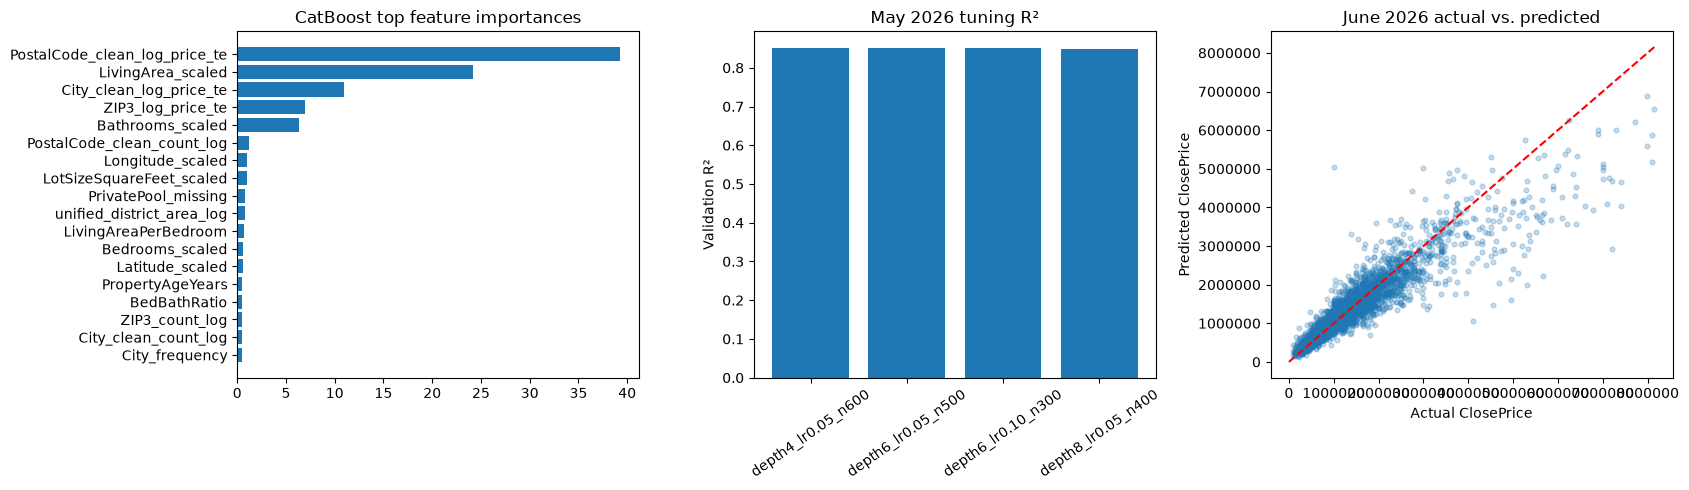

In [12]:
catboost_importance = (
    pd.DataFrame(
        {
            "feature": new_feature_cols,
            "importance": catboost_final.feature_importances_,
        }
    )
    .sort_values("importance", ascending=False)
    .head(18)
)
display(catboost_importance)

validation_plot = tuning_results.sort_values(
    ["max_depth", "learning_rate", "n_estimators"]
)
diagnostic_sample = pd.DataFrame(
    {
        "actual": y_test_final.to_numpy(),
        "predicted": catboost_test_prediction,
        "residual": y_test_final.to_numpy() - catboost_test_prediction,
    }
).sample(n=min(5_000, len(y_test_final)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
axes[0].barh(catboost_importance["feature"][::-1], catboost_importance["importance"][::-1])
axes[0].set_title("CatBoost top feature importances")

axes[1].bar(validation_plot["candidate"], validation_plot["validation_r2"])
axes[1].set_title("May 2026 tuning R²")
axes[1].set_ylabel("Validation R²")
axes[1].tick_params(axis="x", rotation=35)

axes[2].scatter(
    diagnostic_sample["actual"],
    diagnostic_sample["predicted"],
    alpha=0.25,
    s=12,
)
price_max = max(
    diagnostic_sample["actual"].max(),
    diagnostic_sample["predicted"].max(),
)
axes[2].plot([0, price_max], [0, price_max], color="red", linestyle="--")
axes[2].set_title("June 2026 actual vs. predicted")
axes[2].set_xlabel("Actual ClosePrice")
axes[2].set_ylabel("Predicted ClosePrice")
axes[2].ticklabel_format(style="plain", axis="both")

plt.tight_layout()

## Model behavior notes

- **Strengths:** Gradient boosting corrects residual errors sequentially and can learn nonlinear interactions among property, ZIP/city, and school-district features. Histogram-based training and `float32` matrices keep the search practical on the full dataset.
- **Weaknesses:** CatBoost has more interacting hyperparameters than the prior models, is less interpretable than Linear Regression, and can overfit if depth or estimator count is too high.
- **Tuning discipline:** May 2026 is used only for hyperparameter selection, while June 2026 remains untouched until the final model is selected and refit.

## Week 7 outcome

The tuning table records how depth, learning rate, and estimator count affect the May 2026 validation month. The final metrics and comparison table show whether the selected CatBoost model improves upon the Week 6 Random Forest on the untouched June 2026 holdout.